# Pricing Simulator — Model Reference

**Part 1 of 3.** No database required — all cells run with only `pip install -e ".[dev]"`.

| Section | Topic | Needs DB? |
|---------|-------|-----------|
| §0 | Setup & imports | No |
| §1 | RunConfig parameter reference | No |
| §2 | Cohort generation distributions | No |
| §3 | Customer purchase probability model | No |
| §4 | Temporal & geographic context | No |
| §5 | Promo eligibility logic | No |

Continue with `02_simulation_and_metrics.ipynb` to run a full simulation (requires PostgreSQL).


## §0  Setup & imports

Run this notebook from the repo root with the virtual environment active and `pip install -e ".[dev]"`.  
The `DATABASE_URL` environment variable is needed for §6–10. If a `.env` file exists at the repo root it will be loaded automatically by the cell below.


In [1]:
import os
import math
from pathlib import Path

# Load .env from repo root if dotenv is available
try:
    from dotenv import load_dotenv
    _env = Path("../.env")
    if _env.exists():
        load_dotenv(_env)
        print(f"Loaded .env from {_env.resolve()}")
except ImportError:
    pass  # python-dotenv is optional; set DATABASE_URL manually for §6-10

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# app modules — requires: pip install -e . (from repo root)
from app.schemas.run_config import RunConfig
from app.domain.customer import Customer, PurchaseContext
from app.services.simulation.engine import generate_customers, _sample_basket
from app.services.pricing.temporal import temporal_multiplier, is_weekend
from app.services.pricing.geographic import zone_multiplier
from app.services.pricing.promo import PromoRules, promo_eligible
from app.services.metrics.aggregation import build_day_metrics

%matplotlib inline
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print("imports ok")


Loaded .env from /Users/oscarhernandez/Documents/pricing_model_simulator/.env
imports ok


## §1  RunConfig — parameter reference

`RunConfig` is the single source of truth for every simulation run. It is used by both the API (`POST /api/runs`) and the engine directly. The same object controls cohort randomness, pricing rules, promo gates, and the day-count horizon.  

A `model_validator` enforces the constraint `baseline_end_day < experiment_start_day` and that `zones` and `zone_weights` have equal length.


In [2]:
params = [
    # (field, type, default, range/notes, meaning)
    # --- simulation timeline ---
    ("seed",                    "int",         "required",    "any int",                 "RNG seed — same seed always produces the same cohort and outcomes"),
    ("horizon_days",            "int",         90,            "1–500",                   "Total simulated days per run"),
    ("baseline_end_day",        "int",         30,            "< experiment_start_day",  "Last day of the no-treatment baseline phase"),
    ("experiment_start_day",    "int",         31,            "> baseline_end_day, > 1", "First day where control/variant assignment activates"),
    ("customer_count",          "int",         100,           "1–50 000",                "Cohort size — larger N reduces run-to-run variance"),
    # --- baseline pricing ---
    ("baseline_delivery_fee",   "float",       2.99,          "≥ 0",                     "Delivery fee charged to all customers during baseline phase"),
    ("baseline_service_fee",    "float",       1.0,           "≥ 0",                     "Service/handling fee applied in both phases"),
    ("baseline_discount",       "float",       0.0,           "≥ 0",                     "Flat discount deducted during the baseline phase"),
    ("free_delivery_threshold", "float|None", 25.0,          "≥ 0 or None",             "Basket value above which delivery is waived (both phases); None = never free"),
    # --- experiment pricing ---
    ("control_delivery_fee",    "float",       2.99,          "≥ 0",                     "Delivery fee for the control arm during the experiment phase"),
    ("variant_delivery_fee",    "float",       1.99,          "≥ 0",                     "Delivery fee for the variant arm (typically lower to drive uplift)"),
    ("variant_extra_discount",  "float",       0.0,           "≥ 0",                     "Additional promo discount for variant arm; subject to promo rules"),
    # --- economics ---
    ("variable_cost_rate",      "float",       0.35,          "0–1",                     "Fraction of basket subtotal that is variable cost; drives contribution margin"),
    # --- cohort distributions ---
    ("budget_mean",             "float",       40.0,          "≥ 1",                     "Mean of Normal distribution for customer budgets"),
    ("budget_std",              "float",       12.0,          "≥ 0.1",                   "Std dev of Normal distribution for customer budgets"),
    ("propensity_alpha",        "float",       2.0,           "≥ 0.1",                   "Alpha (shape) of Beta distribution for baseline buy propensity"),
    ("propensity_beta",         "float",       5.0,           "≥ 0.1",                   "Beta (shape) of Beta distribution — higher = lower mean propensity"),
    ("basket_log_mean",         "float",       2.2,           "≥ 0",                     "Log-mean of Lognormal for each customer's personal basket center"),
    ("basket_log_sigma",        "float",       0.35,          "≥ 0.01",                  "Log-sigma of Lognormal for basket center draw"),
    # --- geography ---
    ("zones",                   "list[str]",  '["A","B","C"]', "same length as zone_weights", "Zone labels used for aggregation and geo multipliers"),
    ("zone_weights",            "list[float]","[0.5,0.3,0.2]","same length as zones",     "Relative weights for zone assignment (normalised to sum=1 internally)"),
    ("zone_modifiers",          "dict|None",  "None",         "zone→float map",           "Optional override for zone multipliers (defaults: A=1.0, B=1.08, C=0.92)"),
    # --- temporal ---
    ("weekend_factor",          "float",       1.12,          "≥ 0.1",                   "Demand multiplier on Saturdays and Sundays (day 1 = Monday)"),
    ("weekday_factor",          "float",       1.0,           "≥ 0.1",                   "Demand multiplier on Mon–Fri"),
    ("seasonal_amplitude",      "float",       0.05,          "≥ 0",                     "Amplitude of sine seasonality wave (period ≈ 88 days)"),
    # --- promo rules ---
    ("promo_first_order_only",      "bool",  "False",  "True/False",  "Promo discount applies only to a customer's very first purchase"),
    ("promo_max_uses_per_customer", "int",   999,      "≥ 1",         "Maximum lifetime promo orders per customer across the whole run"),
    ("promo_cooldown_days",         "int",   0,        "≥ 0",         "Minimum days between promo uses per customer (0 = no cooldown)"),
    ("campaign_budget",             "float|None", "None", "≥ 0 or None", "Cap on cumulative discount spend; once hit, promo becomes ineligible for everyone"),
]

df_params = pd.DataFrame(params, columns=["Field", "Type", "Default", "Range / notes", "Meaning"])
df_params.index = range(1, len(df_params) + 1)
pd.set_option("display.max_colwidth", 80)
df_params


,Field,Type,Default,Range / notes,Meaning
1,seed,int,required,any int,RNG seed — same seed always produces the same cohort and outcomes
2,horizon_days,int,90,1–500,Total simulated days per run
3,baseline_end_day,int,30,< experiment_start_day,Last day of the no-treatment baseline phase
4,experiment_start_day,int,31,"> baseline_end_day, > 1",First day where control/variant assignment activates
5,customer_count,int,100,1–50 000,Cohort size — larger N reduces run-to-run variance
6,baseline_delivery_fee,float,2.99,≥ 0,Delivery fee charged to all customers during baseline phase
7,baseline_service_fee,float,1.0,≥ 0,Service/handling fee applied in both phases
8,baseline_discount,float,0.0,≥ 0,Flat discount deducted during the baseline phase
9,free_delivery_threshold,float|None,25.0,≥ 0 or None,Basket value above which delivery is waived (both phases); None = never free
10,control_delivery_fee,float,2.99,≥ 0,Delivery fee for the control arm during the experiment phase


## §2  Cohort generation — distributions

When a run starts, `generate_customers` draws a synthetic cohort **once** using the seeded RNG. Each customer is an independent draw from five continuous distributions plus one categorical assignment. The cohort is fixed for the entire run; traits do not change (though stateful fields like `retention_score` evolve day-by-day).

| Trait | Distribution | Parameters (defaults) | Notes |
|-------|-------------|----------------------|-------|
| `budget` | Normal | μ=`budget_mean`=40, σ=`budget_std`=12 | floored at 8 |
| `buy_propensity` | Beta | α=`propensity_alpha`=2, β=`propensity_beta`=5 | clipped [0.02, 0.95] |
| `price_threshold` | Uniform(0.35·budget, 0.85·budget) | derived from budget draw | soft reference price for the purchase model |
| `repeat_boost` | Uniform(0.15, 0.55) | fixed range | extra multiplier after the first purchase |
| `basket_mean` | Lognormal | μ=`basket_log_mean`=2.2, σ=`basket_log_sigma`=0.35 | floored at 4; personal basket center |
| `retention_sensitivity` | Uniform(0.2, 0.9) | fixed range | scales retention score effects |
| `promo_sensitivity` | Uniform(0.2, 0.9) | fixed range | scales promo-absence dampening |
| `zone` | Categorical | `zones` × `zone_weights` | normalised internally |
| `acquisition_channel` | Categorical | organic / paid / referral, equal weights | label only, no model effect |

**Daily basket draw** adds a second layer of noise per order: `basket ~ Lognormal(log(basket_mean), 0.25)`, floored at 3. The σ=0.25 is hard-coded and represents day-to-day variation around each customer's personal basket center.


In [3]:
cfg_cohort = RunConfig(
    seed=42,
    horizon_days=90,
    baseline_end_day=30,
    experiment_start_day=31,
    customer_count=2000,
)
rng_cohort = np.random.default_rng(cfg_cohort.seed)
customers = generate_customers(cfg_cohort, rng_cohort)

budgets       = np.array([c.budget for c in customers])
propensities  = np.array([c.buy_propensity for c in customers])
basket_means  = np.array([c.basket_mean for c in customers])
thresholds    = np.array([c.price_threshold for c in customers])
repeat_boosts = np.array([c.repeat_boost for c in customers])
ret_sens      = np.array([c.retention_sensitivity for c in customers])
zones         = [c.location_zone for c in customers]

print(f"Cohort size: {len(customers)}")
print(f"\nBudget          mean={budgets.mean():.1f}  std={budgets.std():.1f}  min={budgets.min():.1f}  max={budgets.max():.1f}")
print(f"Buy propensity  mean={propensities.mean():.3f}  std={propensities.std():.3f}  min={propensities.min():.3f}  max={propensities.max():.3f}")
print(f"Basket center   mean={basket_means.mean():.1f}  median={np.median(basket_means):.1f}  p95={np.percentile(basket_means, 95):.1f}")
print(f"Price threshold mean={thresholds.mean():.1f}  (as % of budget: {(thresholds/budgets).mean():.1%})")
print(f"Zone counts     { {z: zones.count(z) for z in cfg_cohort.zones} }")

# Daily basket draw samples for one customer
rng_basket = np.random.default_rng(1)
sample_customer = customers[0]
daily_baskets = [float(rng_basket.lognormal(math.log(max(sample_customer.basket_mean, 1.0)), 0.25)) for _ in range(500)]
print(f"\nDaily basket draws for customer 0 (basket_mean={sample_customer.basket_mean:.1f}):")
print(f"  mean={np.mean(daily_baskets):.2f}  std={np.std(daily_baskets):.2f}  min={min(daily_baskets):.2f}  max={max(daily_baskets):.2f}")


Cohort size: 2000

Budget          mean=39.8  std=11.9  min=8.0  max=76.5
Buy propensity  mean=0.287  std=0.162  min=0.020  max=0.912
Basket center   mean=9.6  median=9.0  p95=16.1
Price threshold mean=23.9  (as % of budget: 60.0%)
Zone counts     {'A': 998, 'B': 605, 'C': 397}

Daily basket draws for customer 0 (basket_mean=8.1):
  mean=8.22  std=1.92  min=4.10  max=17.54


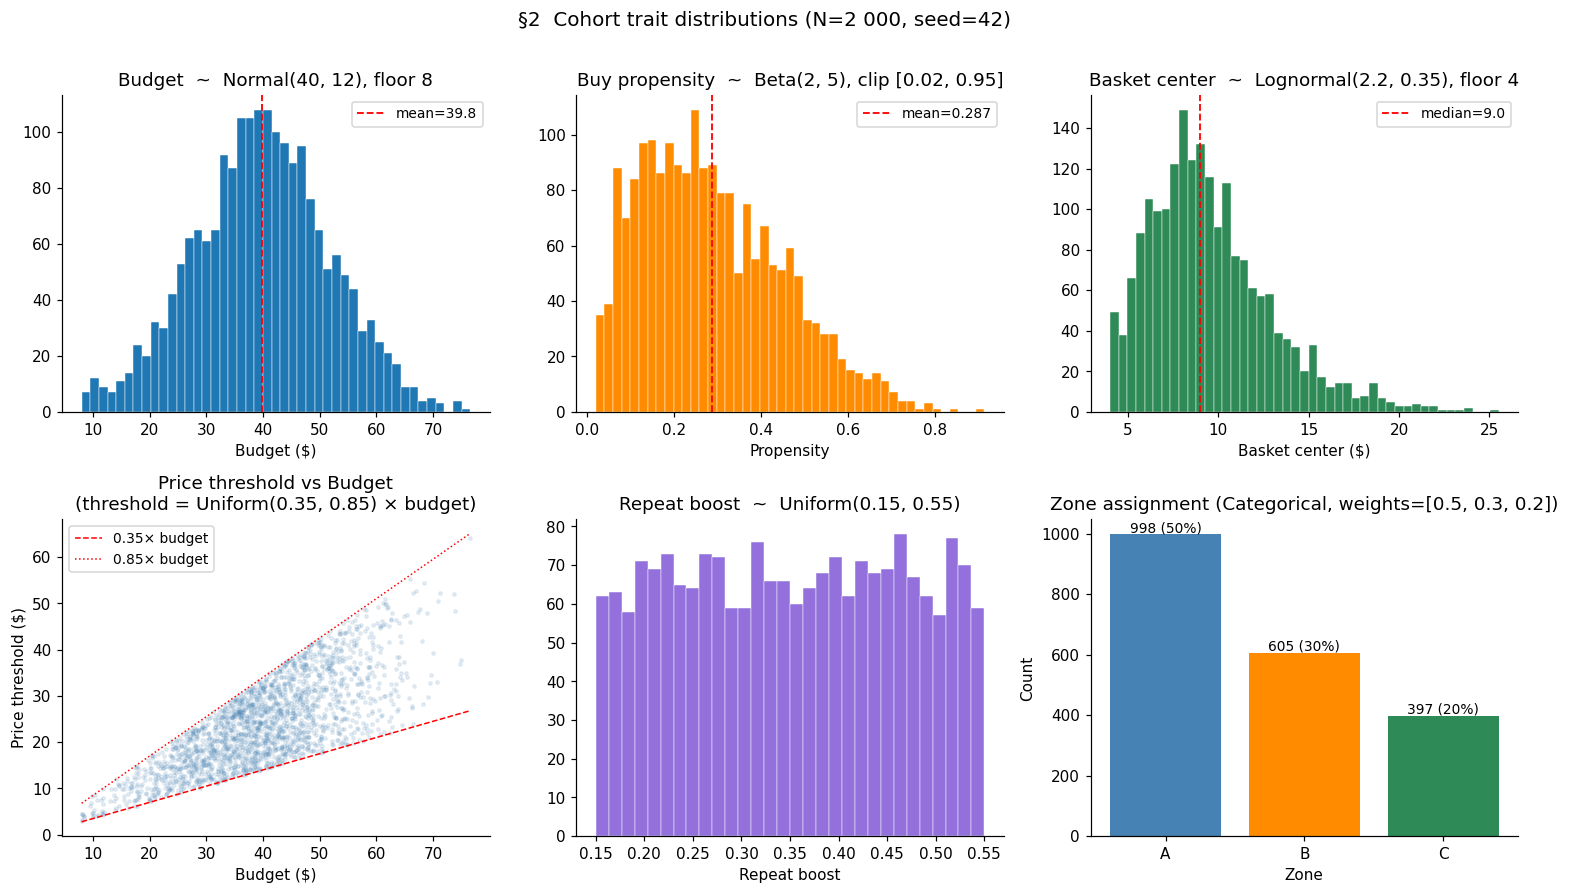

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle("§2  Cohort trait distributions (N=2 000, seed=42)", fontsize=13, y=1.01)

axes[0, 0].hist(budgets, bins=45, edgecolor="white", linewidth=0.3)
axes[0, 0].set_title("Budget  ~  Normal(40, 12), floor 8")
axes[0, 0].set_xlabel("Budget ($)")
axes[0, 0].axvline(budgets.mean(), color="red", lw=1.2, linestyle="--", label=f"mean={budgets.mean():.1f}")
axes[0, 0].legend(fontsize=9)

axes[0, 1].hist(propensities, bins=45, edgecolor="white", linewidth=0.3, color="darkorange")
axes[0, 1].set_title("Buy propensity  ~  Beta(2, 5), clip [0.02, 0.95]")
axes[0, 1].set_xlabel("Propensity")
axes[0, 1].axvline(propensities.mean(), color="red", lw=1.2, linestyle="--", label=f"mean={propensities.mean():.3f}")
axes[0, 1].legend(fontsize=9)

axes[0, 2].hist(basket_means, bins=45, edgecolor="white", linewidth=0.3, color="seagreen")
axes[0, 2].set_title("Basket center  ~  Lognormal(2.2, 0.35), floor 4")
axes[0, 2].set_xlabel("Basket center ($)")
axes[0, 2].axvline(np.median(basket_means), color="red", lw=1.2, linestyle="--", label=f"median={np.median(basket_means):.1f}")
axes[0, 2].legend(fontsize=9)

axes[1, 0].scatter(budgets, thresholds, alpha=0.12, s=5, color="steelblue")
axes[1, 0].set_title("Price threshold vs Budget\n(threshold = Uniform(0.35, 0.85) × budget)")
axes[1, 0].set_xlabel("Budget ($)")
axes[1, 0].set_ylabel("Price threshold ($)")
_x = np.linspace(budgets.min(), budgets.max(), 100)
axes[1, 0].plot(_x, 0.35 * _x, lw=1, color="red", linestyle="--", label="0.35× budget")
axes[1, 0].plot(_x, 0.85 * _x, lw=1, color="red", linestyle=":", label="0.85× budget")
axes[1, 0].legend(fontsize=9)

axes[1, 1].hist(repeat_boosts, bins=30, edgecolor="white", linewidth=0.3, color="mediumpurple")
axes[1, 1].set_title("Repeat boost  ~  Uniform(0.15, 0.55)")
axes[1, 1].set_xlabel("Repeat boost")

zone_counts = {z: zones.count(z) for z in cfg_cohort.zones}
bars = axes[1, 2].bar(zone_counts.keys(), zone_counts.values(), color=["steelblue", "darkorange", "seagreen"])
axes[1, 2].set_title("Zone assignment (Categorical, weights=[0.5, 0.3, 0.2])")
axes[1, 2].set_xlabel("Zone")
axes[1, 2].set_ylabel("Count")
for bar, (z, cnt) in zip(bars, zone_counts.items()):
    axes[1, 2].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 8,
                    f"{cnt} ({cnt/len(customers):.0%})", ha="center", fontsize=9)

plt.tight_layout()
plt.show()


## §3  Customer purchase probability model

Each customer-day the engine calls `customer.compute_purchase_probability(offered_price, day, context)`. The result is a value in **[0, 1]** that is compared to a single uniform draw `u` to produce a Bernoulli purchase decision.

### Formula

```
p = base × price_effect × repeat_effect × calendar × retention
```

clipped to [0, 1], where:

**`base`** = `buy_propensity` — the customer's intrinsic tendency to buy on any given day.

**`price_effect`** = `1 / (1 + max(0, r − 1))` where `r = min(offered_price / price_threshold, 3.0)`
- Equals 1.0 when the offered price is at or below `price_threshold`
- Declines smoothly as price rises above `price_threshold`
- Reaches a floor of 0.25 when price = 3× threshold
- Drops to **0.0** if `offered_price > budget` (hard budget gate)

**`repeat_effect`**:
- New customer (no prior purchases): `max(0.15, 1 − 0.45 × promo_sensitivity)` — new customers buy less often, especially promo-sensitive ones
- Repeat customer: `1 + repeat_boost × (1 + 0.1 × purchase_count)` — loyalty lift that grows with order history

**`calendar`** = `temporal_multiplier × geographic_multiplier × (0.85 if not promo_eligible else 1.0)`
- The 0.85 promo-ineligibility penalty reflects reduced incentive when no discount is available

**`retention`** = `1 + 0.15 × (retention_score − 1) × retention_sensitivity`
- `retention_score` starts at 1.0, rises after purchases (`+0.12 × retention_sensitivity`, cap 2.5), and decays on inactivity (`−0.01 × min(days_since_purchase, 30)` per day, floor 1.0)


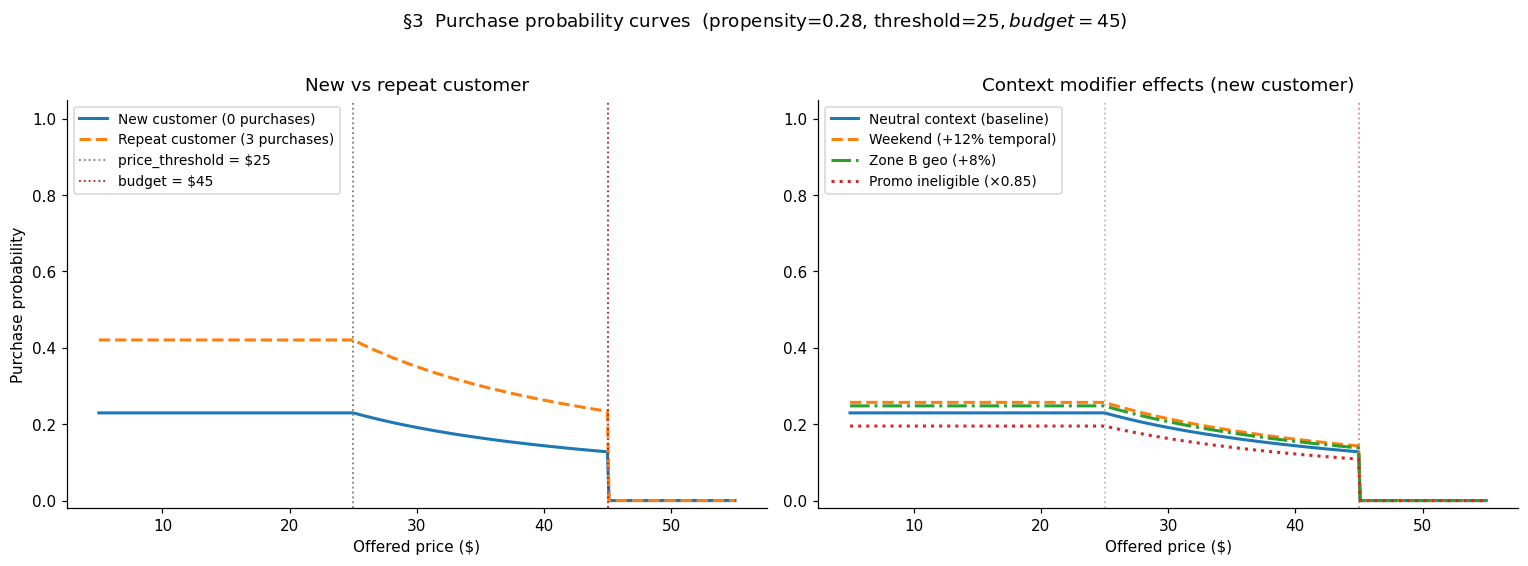


New customer probabilities:
  At price_threshold ($25):        p = 0.2296
  At 2× price_threshold ($50):  p = 0.0000
  At budget ($45):                 p = 0.1276
  At budget + $0.01 ($45.01):    p = 0.0000  (hard gate)


In [5]:
# Representative customer: mid-range propensity and budget
c_base = Customer(
    customer_id=-1, customer_index=0,
    budget=45.0, buy_propensity=0.28,
    price_threshold=25.0, repeat_boost=0.35,
    basket_mean=12.0, location_zone="A",
    retention_sensitivity=0.6, promo_sensitivity=0.4,
)

ctx_neutral  = PurchaseContext(temporal_multiplier=1.0, geographic_multiplier=1.0, promo_eligible=True)
ctx_weekend  = PurchaseContext(temporal_multiplier=1.12, geographic_multiplier=1.0, promo_eligible=True)
ctx_no_promo = PurchaseContext(temporal_multiplier=1.0,  geographic_multiplier=1.0, promo_eligible=False)
ctx_zone_b   = PurchaseContext(temporal_multiplier=1.0,  geographic_multiplier=1.08, promo_eligible=True)

# Repeat customer with 3 purchases and elevated retention score
c_repeat = Customer(
    customer_id=-1, customer_index=0,
    budget=45.0, buy_propensity=0.28,
    price_threshold=25.0, repeat_boost=0.35,
    basket_mean=12.0, location_zone="A",
    retention_sensitivity=0.6, promo_sensitivity=0.4,
    has_purchased_before=True, purchase_count=3, retention_score=1.36,
)

prices = np.linspace(5, 55, 400)
p_new      = [c_base.compute_purchase_probability(pr, 1, ctx_neutral)  for pr in prices]
p_repeat   = [c_repeat.compute_purchase_probability(pr, 1, ctx_neutral) for pr in prices]
p_weekend  = [c_base.compute_purchase_probability(pr, 1, ctx_weekend)  for pr in prices]
p_no_promo = [c_base.compute_purchase_probability(pr, 1, ctx_no_promo) for pr in prices]
p_zone_b   = [c_base.compute_purchase_probability(pr, 1, ctx_zone_b)   for pr in prices]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("§3  Purchase probability curves  (propensity=0.28, threshold=$25, budget=$45)", fontsize=12, y=1.02)

ax1.plot(prices, p_new,    label="New customer (0 purchases)",       lw=2)
ax1.plot(prices, p_repeat, label="Repeat customer (3 purchases)",    lw=2, linestyle="--")
ax1.axvline(c_base.price_threshold, color="gray",  lw=1.2, linestyle=":", label=f"price_threshold = ${c_base.price_threshold:.0f}")
ax1.axvline(c_base.budget,          color="firebrick", lw=1.2, linestyle=":", label=f"budget = ${c_base.budget:.0f}")
ax1.set_xlabel("Offered price ($)")
ax1.set_ylabel("Purchase probability")
ax1.set_title("New vs repeat customer")
ax1.legend(fontsize=9)
ax1.set_ylim(-0.02, 1.05)

ax2.plot(prices, p_new,      label="Neutral context (baseline)",     lw=2)
ax2.plot(prices, p_weekend,  label="Weekend (+12% temporal)",        lw=2, linestyle="--")
ax2.plot(prices, p_zone_b,   label="Zone B geo (+8%)",               lw=2, linestyle="-.")
ax2.plot(prices, p_no_promo, label="Promo ineligible (×0.85)",       lw=2, linestyle=":")
ax2.axvline(c_base.price_threshold, color="gray",  lw=1.2, linestyle=":", alpha=0.5)
ax2.axvline(c_base.budget,          color="firebrick", lw=1.2, linestyle=":", alpha=0.5)
ax2.set_xlabel("Offered price ($)")
ax2.set_title("Context modifier effects (new customer)")
ax2.legend(fontsize=9)
ax2.set_ylim(-0.02, 1.05)

plt.tight_layout()
plt.show()

# Numeric summary at threshold price
p_at_threshold = c_base.compute_purchase_probability(c_base.price_threshold, 1, ctx_neutral)
p_at_2x        = c_base.compute_purchase_probability(c_base.price_threshold * 2, 1, ctx_neutral)
print(f"\nNew customer probabilities:")
print(f"  At price_threshold (${c_base.price_threshold:.0f}):        p = {p_at_threshold:.4f}")
print(f"  At 2× price_threshold (${c_base.price_threshold*2:.0f}):  p = {p_at_2x:.4f}")
print(f"  At budget (${c_base.budget:.0f}):                 p = {c_base.compute_purchase_probability(c_base.budget, 1, ctx_neutral):.4f}")
print(f"  At budget + $0.01 (${c_base.budget+0.01:.2f}):    p = {c_base.compute_purchase_probability(c_base.budget+0.01, 1, ctx_neutral):.4f}  (hard gate)")


## §4  Temporal & geographic context

Two **deterministic** multipliers scale every customer's purchase probability each day. They shift demand uniformly across the cohort — no new randomness is introduced.

### Temporal multiplier

```
temporal(day) = base(day) × (1 + seasonal_amplitude × sin(day / 14))
```

- `base(day)` = `weekend_factor` (default 1.12) if day maps to Sat/Sun, else `weekday_factor` (default 1.0)  
- Day 1 = Monday; weekends occur at day % 7 in {6, 0} (i.e. days 6, 7, 13, 14, ...)
- The sine component has period **2π × 14 ≈ 88 days**, producing one full seasonal wave across a 90-day run
- Default amplitude 0.05 → ±5% variation around the weekday/weekend base

### Geographic multiplier

Each customer is assigned a zone at cohort creation. Default multipliers:

| Zone | Multiplier | Interpretation |
|------|-----------|----------------|
| A    | 1.00      | Reference demand level |
| B    | 1.08      | 8% higher demand (e.g. denser urban area) |
| C    | 0.92      | 8% lower demand (e.g. suburban / price-sensitive) |

Override with `zone_modifiers: {"A": 1.0, "B": 1.15, "C": 0.85}` in `RunConfig`.


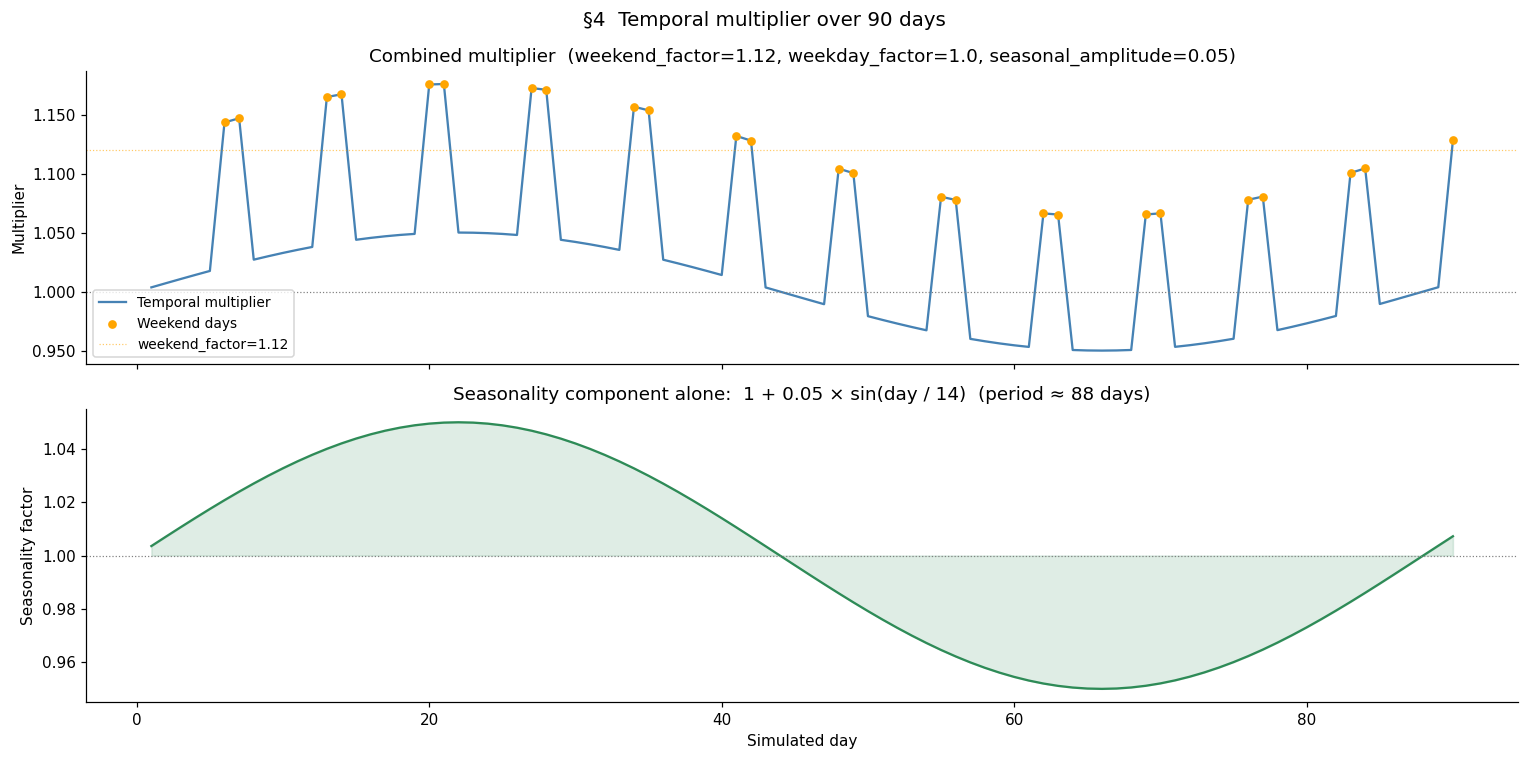


--- Geographic zone multipliers (defaults) ---
Zone  Multiplier
   A        1.00
   B        1.08
   C        0.92

Weekday/weekend split over 90 days:
  Weekdays: 65  Weekends: 25
  Mean temporal multiplier (weekdays): 1.0001
  Mean temporal multiplier (weekends): 1.1201


In [6]:
days = np.arange(1, 91)
t_mults  = np.array([temporal_multiplier(d, weekend_factor=1.12, weekday_factor=1.0, seasonal_amplitude=0.05) for d in days])
weekends = np.array([is_weekend(d) for d in days])
sine_only = 1.0 + 0.05 * np.sin(days / 14.0)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
fig.suptitle("§4  Temporal multiplier over 90 days", fontsize=13)

axes[0].plot(days, t_mults, lw=1.5, color="steelblue", label="Temporal multiplier")
axes[0].scatter(days[weekends], t_mults[weekends], color="orange", s=22, zorder=5, label="Weekend days")
axes[0].axhline(1.0, color="gray", lw=0.8, linestyle=":")
axes[0].axhline(1.12, color="orange", lw=0.8, linestyle=":", alpha=0.6, label="weekend_factor=1.12")
axes[0].set_ylabel("Multiplier")
axes[0].set_title("Combined multiplier  (weekend_factor=1.12, weekday_factor=1.0, seasonal_amplitude=0.05)")
axes[0].legend(fontsize=9)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.3f}"))

axes[1].plot(days, sine_only, lw=1.5, color="seagreen")
axes[1].axhline(1.0, color="gray", lw=0.8, linestyle=":")
axes[1].fill_between(days, 1.0, sine_only, alpha=0.15, color="seagreen")
axes[1].set_xlabel("Simulated day")
axes[1].set_ylabel("Seasonality factor")
axes[1].set_title("Seasonality component alone:  1 + 0.05 × sin(day / 14)  (period ≈ 88 days)")

plt.tight_layout()
plt.show()

# Zone multiplier table
print("\n--- Geographic zone multipliers (defaults) ---")
zone_df = pd.DataFrame(
    [(z, zone_multiplier(z)) for z in ["A", "B", "C"]],
    columns=["Zone", "Multiplier"]
)
print(zone_df.to_string(index=False))

print("\nWeekday/weekend split over 90 days:")
print(f"  Weekdays: {(~weekends).sum()}  Weekends: {weekends.sum()}")
print(f"  Mean temporal multiplier (weekdays): {t_mults[~weekends].mean():.4f}")
print(f"  Mean temporal multiplier (weekends): {t_mults[weekends].mean():.4f}")


## §5  Promo eligibility

Variant-arm customers **may** receive `variant_extra_discount` on each purchase, but all four gates below must pass simultaneously:

| Gate | Rule | Config field |
|------|------|--------------|
| Campaign budget | `cumulative_discount_spend < campaign_budget` | `campaign_budget` |
| First-order only | `customer.purchase_count == 0` (if enabled) | `promo_first_order_only` |
| Per-customer max uses | `customer.promo_uses_to_date < max_uses_per_customer` | `promo_max_uses_per_customer` |
| Cooldown | `current_day − last_promo_day >= cooldown_days` | `promo_cooldown_days` |

**Important:** when `promo_eligible` is `False`, the `calendar` term in the purchase model is multiplied by **0.85** — a mild dampening that reflects reduced purchase incentive when no discount is on offer. This affects all customers in the variant arm who have hit a promo restriction, not just those actively blocked by a hard gate.

Note that `promo_eligible` is checked **before** the purchase decision. If a customer is promo-eligible but does not purchase, their promo state is not updated.


In [7]:
def make_customer(purchase_count=0, promo_uses_to_date=0, last_promo_day=None):
    return Customer(
        customer_id=-1, customer_index=0,
        budget=40.0, buy_propensity=0.3,
        price_threshold=20.0, repeat_boost=0.35,
        basket_mean=12.0, location_zone="A",
        purchase_count=purchase_count,
        has_purchased_before=(purchase_count > 0),
        promo_uses_to_date=promo_uses_to_date,
        last_promo_day=last_promo_day,
    )

scenarios = [
    # (description, customer_kwargs, rules, cum_disc, current_day)
    ("New customer, no restrictions (all defaults)",
     make_customer(0, 0, None), PromoRules(), 0.0, 5),

    ("Repeat customer, first_order_only=True",
     make_customer(2, 1, None), PromoRules(first_order_only=True), 0.0, 5),

    ("New customer, first_order_only=True",
     make_customer(0, 0, None), PromoRules(first_order_only=True), 0.0, 5),

    ("Customer exhausted max_uses (max=2, used=2)",
     make_customer(3, 2, None), PromoRules(max_uses_per_customer=2), 0.0, 5),

    ("In cooldown (last promo day=1, cooldown=7, current day=5)",
     make_customer(1, 1, 1), PromoRules(cooldown_days=7), 0.0, 5),

    ("Past cooldown (last promo day=1, cooldown=7, current day=10)",
     make_customer(1, 1, 1), PromoRules(cooldown_days=7), 0.0, 10),

    ("Campaign budget exhausted ($50 cap, spent $50)",
     make_customer(0, 0, None), PromoRules(campaign_budget=50.0), 50.0, 5),

    ("Campaign budget not exhausted ($50 cap, spent $40)",
     make_customer(0, 0, None), PromoRules(campaign_budget=50.0), 40.0, 5),
]

rows = []
for desc, c, rules, cum_disc, day in scenarios:
    eligible = promo_eligible(c, day, rules, cum_disc)
    rows.append({"Scenario": desc, "Day": day, "Cum. discount": f"${cum_disc:.0f}", "Eligible": "YES" if eligible else "NO"})

df_promo = pd.DataFrame(rows)
print(df_promo.to_string(index=False))


                                                    Scenario  Day Cum. discount Eligible
                New customer, no restrictions (all defaults)    5            $0      YES
                      Repeat customer, first_order_only=True    5            $0       NO
                         New customer, first_order_only=True    5            $0      YES
                 Customer exhausted max_uses (max=2, used=2)    5            $0       NO
   In cooldown (last promo day=1, cooldown=7, current day=5)    5            $0       NO
Past cooldown (last promo day=1, cooldown=7, current day=10)   10            $0      YES
              Campaign budget exhausted ($50 cap, spent $50)    5           $50       NO
          Campaign budget not exhausted ($50 cap, spent $40)    5           $40      YES
